In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("house_data_cleaned.csv")

In [3]:
#独热编码
df=pd.get_dummies(df,columns=['neighborhood'],dtype=int,drop_first=True)
"""更改部分参数里的columns"""

'更改部分参数里的columns'

In [5]:
#标准化
cols_to_scale=[
    'area_sqm',
    'bedrooms',
    'bathrooms',
    'age_years',
    'distance_to_center_km']
cols_y=['price_k']
#下面两行用于还原最后w系数
means=df[cols_to_scale].mean(axis=0)
stds=df[cols_to_scale].std(axis=0,ddof=0)
#标准化代码
df[cols_to_scale]=(df[cols_to_scale]-means)/stds
#特征值记录
feature_names = df.drop(cols_y, axis=1).columns.tolist()
"""更改部分：cols_to_scale,cols_y,df,cols_y只有一个值"""

'更改部分：cols_to_scale,cols_y,df,cols_y只有一个值'

In [6]:
#变量定义
Y=df[cols_y].values.flatten()
X_raw=df.drop(cols_y,axis=1).values
m=X_raw.shape[0]

In [7]:
#扩充矩阵（这个格子只运行一次）
X=np.hstack((np.ones((m,1)),X_raw))
n=X.shape[1]

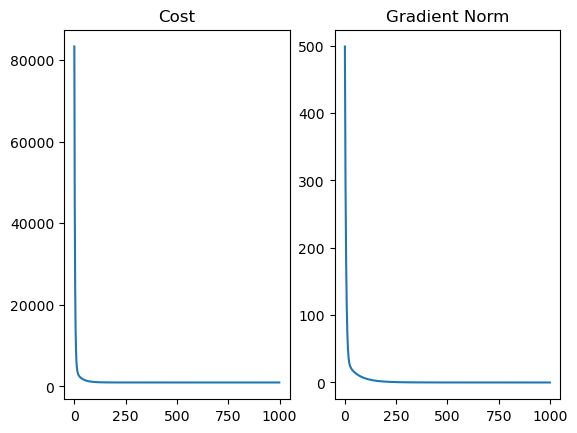

In [9]:
#梯度下降
alpha=0.1
n_iters=1000
cost_history=[]
grad_history=[]
w=np.zeros((n,))
for i in range(n_iters):
    pred=X@w
    err=pred-Y
    grad=(X.T@err)/m
    w=w-alpha*grad
    cost_history.append(((err**2).mean())/2)
    grad_history.append(np.linalg.norm(grad))


fig,axes=plt.subplots(1,2)
axes[0].plot(range(n_iters),cost_history)
axes[0].set_title("Cost")
axes[1].plot(range(n_iters),grad_history)
axes[1].set_title("Gradient Norm")
plt.show()

In [10]:
#w还原
cols_to_scale_idx = [feature_names.index(col) for col in cols_to_scale]

intercept_scaled = w[0]
coef_scaled = w[1:].copy()
coef_original = coef_scaled.copy()

means_arr = means[cols_to_scale].to_numpy()
stds_arr = stds[cols_to_scale].to_numpy()

coef_original[cols_to_scale_idx] = coef_scaled[cols_to_scale_idx] / stds_arr

intercept_original = intercept_scaled - np.sum(
    coef_scaled[cols_to_scale_idx] * means_arr / stds_arr
)

w_original = np.hstack([
    intercept_original,
    coef_original
])

In [11]:
w_original

array([ -6.48257704,   3.22943197,  21.05023854,   4.84987093,
        -1.73499831,  15.13097308,  -4.56298063,  12.61122873,
        82.42565658,  51.3731818 , 107.41303522])